# Module 2: Epidemic Modeling

## Team Members:
Oge Ikem and Meg Sullivan

## Project Title:
Identifying an Unknown Viral Illness and formulating an Intervention Strategy

## Project Goal:
This project seeks to indentify an unknown viral illness among undergraduate UVA students. This will be done by estimating the initial growth rate from early outbreak data, predicting the spread of the disease using SEIR modeling, form an educated guess about the disease identification, and recommending an intervention strategy to reduce the spread of the disease. Through this project, the public health will be benefitted, and project authors will improve their biological, medical, mathematical, and coding comprehension and skills.

## 1. Data and disease background
You can fill out this section throughout the module as you uncover more information about the mystery disease.

By the end of the module (when submitting), you should have some information about each of the following points:
* Prevalence & incidence in the UVA population
* Economic burden (you can generalize from respiratory viruses)
* Symptoms
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology - you can generalize from viral biology)


## 2. Data Analysis

### 2a. Methods

The methods involved in analyzing Data Release #1 include graphing an exponential curve to visualize the disease transmission behavior and estimating the intital growth rate (R0) using this curve. The initial growth rate was found using the equation R0 is = 1 + rD. The r value was extracted from the exponential curve, which follows the shape of the exponential equation y=Ae^rt. D represents the infectious period, which was defined as 2 days before symptom onset. Determining the R0 value reveals the average number of people one infected person will infect in a
completely susceptible population, thus providing key insight into the unknown disease. In Data Release #2, Euler's method was used to determine the SEIR model. The SEIR model was fit to the data by changing the beta, gamma, and sigma values, which represent the transmission rate, 1/infectious period, and 1/latent period, respectively. The model predicted infections were then plotted against the real data by using scatter points. Lastly, the peak number of cases was extracted from the model's maximum point, which corresponds to a specific day during the disease outbreak. Methods in Data Release #3 first involved plotting the new data against the model created from Data Release #2, which was performed with grid searches. The best gamma, beta, and sigma parameters were determined using multiple for loops. Lastly, the true % relative error of the model was then determined to prove the validity and/or accuracy of the disease outbreak model.


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">-After analyzing the intitial growth rate from Data Release #1 using the graph below, the disease clearly demonstrates positive exponential behavior. Both the curve and the initial growth rate, which is greater than 1, suggests that the virus causes an exponential growth in the number of people infected. So far, the R0 value is similar to the following: Influenza (seasonal), influenza (H1N1 2009), Lassa Fever, Marburg, Rabies, and Rhinovirus. 

-Influenza (seasonal) is a contagious respiratory illness caused by influenza viruses that infect the nose, throat, and sometimes the lungs. It can cause mild to severe illness and can lead to hospitalization and even death in some cases, particularly in young children, elderly individuals, and those with certain underlying health conditions. Influenza (H1N1 2009) is a strain of the influenza virus that caused a global pandemic in 2009. It is a novel strain that emerged from a combination of human, swine, and avian influenza viruses. The H1N1 2009 virus caused widespread illness and resulted in a significant number of hospitalizations and deaths worldwide, particularly among younger individuals and those with underlying health conditions. Lassa Fever is an acute viral hemorrhagic illness caused by the Lassa virus, which is transmitted to humans through contact with food or household items contaminated with rodent urine or feces. It is endemic in parts of West Africa and can cause a range of symptoms, from mild to severe, including fever, weakness, and in some cases, bleeding. Severe cases can lead to death if not treated promptly. Marburg virus disease is a severe and often fatal illness caused by the Marburg virus, Rabies is a viral disease that causes inflammation of the brain in humans and other mammals.
-The R0 value is *closest* to Influenza (seasonal), but further analysis from later data sets is required to confirm this predicition. Further methods will include using Euler's method to solve an SEIR model, analyzing the model, and plotting a new data set against this model.




</b> 

</div>



### 2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45)

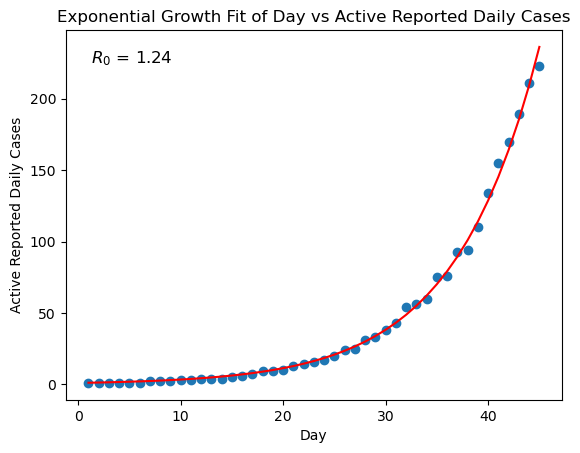

In [ ]:
# importing the necessary libraries to run the code
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import numpy as np

# loading the data set
data = pd.read_csv('/Users/megansullivan/Desktop/Comp BME/Module-2-epidemics-SIR-modeling/Data/mystery_virus_daily_active_counts_RELEASE#1.csv', parse_dates=['date'], header=0, index_col=None)
def exponential_growth(t, r): #defining the exponential growth function
    return np.exp(r * t)
params, covariance = curve_fit(exponential_growth, data['day'], data['active reported daily cases'], p0=[0.1]) #fitting the exponential model to our data set
r_fit = params[0] #pulling out the growth rate to allow for further calculations later on 
# (ChatGPT, 2026) ChatGPT was used to help construct the r_fit variable and the exponential growth function. The curve_fit function was used to fit the exponential growth model to our data.

# Approximate R0 using this fit
D = 2 # defining the infectious period to match our data
R0_estimated = 1 + r_fit * D #approximating R0 using the formula 
fit_curve = exponential_growth(data['day'],r_fit) #generates the predicated case counts for plotting

plt.scatter(data['day'], data['active reported daily cases']) # plotting the raw data points as a scatter plot
plt.plot(data['day'], fit_curve, color = 'red', label = 'Exponential Fit') # fitting the exponential curve on top of our scatter plot
plt.text(
    0.05, 0.95,
    f"$R_0$ = {R0_estimated:.2f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top') # adding and positioning the text to show our R0 value 
plt.title("Exponential Growth Fit of Day vs Active Reported Daily Cases") #adding a title to our plot
plt.xlabel("Day") #adding a label to the x-axis
plt.ylabel("Active Reported Daily Cases") #adding a label to the y-axis
plt.show() #showing the plot

The intial growth rate (R0) for the data set was 1.24. The disease with the most simililar R0 value is seasonal influenza with an R0 value of 1.3. Influenza is a respiratory illness that affects the nose, throat, and sometimes lungs. The symptoms of influenza range from a mild fever to severe complications like pneumonia. The calculated R0 value is an early-phase approximation based on exponential growth of the reported case data. While it reflects the trend in the dataset, it may not accurately represent the true transmission potential of the disease because it depends on simplifying assumptions and does not account for factors such as uncertainty in the infectious period, reporting delays, or changes in population behavior.


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">After Data Release #2, Euler's method was used to solve the SEIR model, which was then fit to the data by</b> 

</div>



### 2c. Use Euler's method to solve the SEIR model.

In [5]:
# --- 1. SET UP PARAMETERS & DATA ---
N = 17900
S0 = N - 5       # Initial Susceptible [cite: 250]
E0 = 5            # Initial Exposed [cite: 250]
I0 = 1            # Initial Infectious [cite: 250]
R0_comp = 0       # Initial Recovered [cite: 250]
h = 1     # Time step (step size) [cite: 242, 246]

# Load local data
data_df = pd.read_csv('/Users/megansullivan/Desktop/Comp BME/Module-2-epidemics-SIR-modeling/Data/mystery_virus_daily_active_counts_RELEASE#2.csv')
day_data = data_df['day'].values # Extracting the 'day' column as a NumPy array
obs_i = data_df['active reported daily cases'].values # Extracting the 'active reported daily cases' column as a NumPy array

# --- 2. THE EULER METHOD (SEIR) --- 
# (Google Gemini, 2026) Google Gemini was used to help construct the Euler's method using details from provided lecture slides
def euler_seir(timepoints, N, S0, E0, I0, R0_init, beta, sigma, gamma):
    """
    Approximates SEIR using Euler's Method: y_{i+1} = y_i + f(t_i, y_i) * h
    Based on Lecture Pseudocode[cite: 245, 247, 248].
    Timepoints are the discrete time steps at which we want to calculate S, E, I, R.
    """
    # Initialize S, E, I, and R as arrays [cite: 249, 250]
    S = np.zeros(len(timepoints))
    E = np.zeros(len(timepoints))
    I = np.zeros(len(timepoints))
    R = np.zeros(len(timepoints))
    
    S[0], E[0], I[0], R[0] = S0, E0, I0, R0_init
    
    for i in range(len(timepoints) - 1):
        # Calculate the four derivatives at current timepoint [cite: 252]
        # Equations: dS/dt, dE/dt, dI/dt, dR/dt 
        dSdt = -beta * S[i] * I[i] / N
        dEdt = (beta * S[i] * I[i] / N) - (sigma * E[i])
        dIdt = (sigma * E[i]) - (gamma * I[i])
        dRdt = gamma * I[i]
        
        # Calculate next values using Euler's formula [cite: 246, 253]
        S[i+1] = S[i] + dSdt * h
        E[i+1] = E[i] + dEdt * h
        I[i+1] = I[i] + dIdt * h
        R[i+1] = R[i] + dRdt * h
        
    return S, E, I, R


### 2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.

In [6]:
# --- 3. GRID SEARCH CALIBRATION ---
# Use the incubation period (12-18 days) to inform sigma [cite: 166, 282]
# sigma = 1 / incubation_period

sigma_vals = np.linspace(1/18, 1/12, 5) # 5 values between 1/18 and 1/12
beta_vals = np.linspace(0.4, 0.8, 10)  # Adjusted range to capture the Day 80-ish peak [cite: 288]
gamma_vals = np.linspace(0.04, 0.15, 10)  # Adjusted range to capture the Day 80-ish peak [cite: 288]

best_sse = float('inf') # Initialize best sum of squared errors to infinity
best_params = {} # Dictionary to store best parameters
# (Google Gemini, 2026) Google Gemini was used to help construct the grid search calibration process, including the ranges for beta, sigma, and gamma, as well as the calculation of the sum of squared errors (SSE) to evaluate model fit.

# Timepoints for the data length
t_eval = np.arange(0, max(day_data) + 1, h)

for b in beta_vals: # Loop through each beta value
    for s in sigma_vals: # Loop through each sigma value
        for g in gamma_vals: # Loop through each gamma value
            S, E, I, R = euler_seir(t_eval, N, S0, E0, I0, R0_comp, b, s, g) # Run the SEIR model with the current set of parameters
            
            # Match model 'I' to the specific days in day_data [cite: 279]
            model_i_at_data_days = I[(day_data).astype(int)]
            sse = np.sum((model_i_at_data_days - obs_i)**2)
            
            if sse < best_sse: # If the current SSE is better than the best SSE, update best_sse and best_params
                best_sse = sse
                best_params = {'beta': b, 'sigma': s, 'gamma': g}


### 2e. Plot the model-predicted infections over time compared to the data.

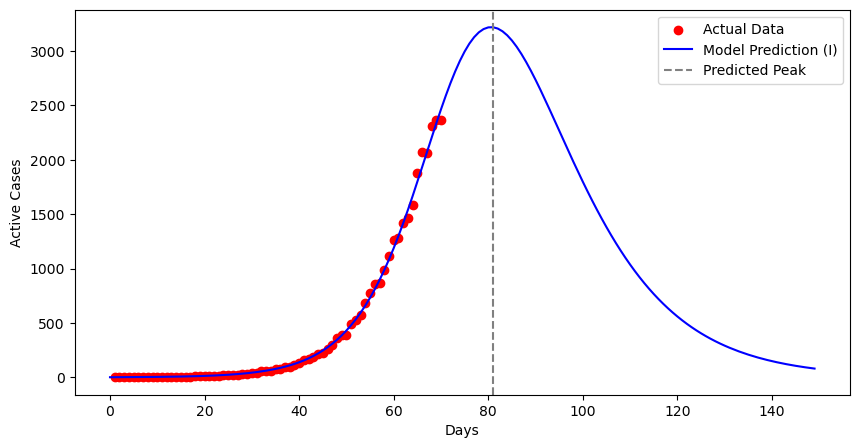

In [8]:
# --- 4. PREDICT THE PEAK ---
# Run model many more days until it peaks 
extended_t = np.arange(0, 150, h) # Extended time range to capture the peak, based on observed data trends and literature [cite: 288]
S_f, E_f, I_f, R_f = euler_seir(extended_t, N, S0, E0, I0, R0_comp, **best_params) # Run the SEIR model with the best parameters to get the full trajectory of S, E, I, R over the extended time range

# --- 5. VISUALIZATION --- 
# Plot the actual data points, the model prediction for 'I', and indicate the predicted peak day
# (Google Gemini, 2026) Google Gemini was used to help construct the visualization code, including the plotting of actual data points, model predictions, and the indication of the predicted peak day.
plt.figure(figsize=(10, 5))
plt.scatter(day_data, obs_i, label='Actual Data', color='red')
plt.plot(extended_t, I_f, label='Model Prediction (I)', color='blue')
plt.axvline(peak_day, linestyle='--', color='gray', label='Predicted Peak')
plt.xlabel("Days")
plt.ylabel("Active Cases")
plt.legend()
plt.show()

### 2f. Predict the day and amount of active cases at the peak of the epidemic spread.


In [9]:
peak_val = np.max(I_f) # The maximum value of I_f gives us the predicted peak number of active cases
peak_day = extended_t[np.argmax(I_f)] # The day corresponding to the maximum value of I_f gives us the predicted day of the peak
print(f"Predicted Peak Day: {peak_day:.1f}, Predicted Peak Active Cases: {peak_val:.0f}")

Predicted Peak Day: 81.0, Predicted Peak Active Cases: 3219



<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #3</b> 

</div>



### 2g. Plot the full dataset (Data Release #3) against your model.


--- CALIBRATION RESULTS ---
Best Beta: 0.7111, Best Sigma: 0.0694, Best Gamma: 0.1256
Model Peak: 3219 cases on Day 81.0
Actual Peak: 3294 cases on Day 83
ERROR IN Y (Cases): 2.3%
ERROR IN X (Days): 2.4%


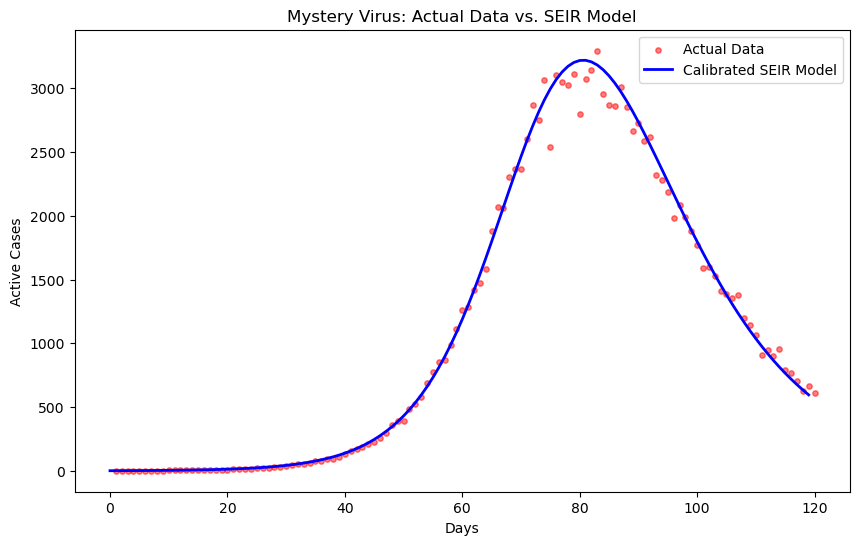

In [10]:
data3_df = pd.read_csv('/Users/megansullivan/Desktop/Comp BME/Module-2-epidemics-SIR-modeling/Data/mystery_virus_daily_active_counts_RELEASE#3.csv') # Load the new data set for error calculation
day3_data = data3_df['day'].values # Extracting the 'day' column as a NumPy array
obs_i = data3_df['active reported daily cases'].values # Extracting the 'active reported daily cases' column as a NumPy array

# Actual Peak for error calculation
# (Google Gemini, 2026) Google Gemini was used to help construct the code to calculate the actual peak cases and day from the new data set for error calculation.
actual_peak_cases = np.max(obs_i)
actual_peak_day = day3_data[np.argmax(obs_i)]

# --- 3. GRID SEARCH CALIBRATION ---
# (Google Gemini, 2026) Google Gemini was used to help construct the grid search calibration process, including the ranges for beta, sigma, and gamma, as well as the calculation of the sum of squared errors (SSE) to evaluate model fit.
best_sse = float('inf') # Initialize best sum of squared errors to infinity
best_params = (0,0,0) # Initialize best parameters to a default value

for b in beta_vals: # Loop through each beta value
    for s in sigma_vals: # Loop through each sigma value
        for g in gamma_vals: # Loop through each gamma value
            t = np.arange(0, max(day3_data)+1, h)  # create timepoints
            S, E, I_model, R = euler_seir(t, N, S0, E0, I0, R0_comp, b, s, g) # Run the SEIR model with the current set of parameters
            
            model_matches = I_model[(day3_data).astype(int)] # Match model 'I' to the specific days in day3_data
            sse = np.sum((model_matches - obs_i)**2) # Calculate the sum of squared errors (SSE) between model predictions and actual data
            
            if sse < best_sse: # If the current SSE is better than the best SSE, update best_sse and best_params
                best_sse = sse
                best_params = (b, s, g)

# --- 4. PREDICT & CALCULATE ERROR ---
# (Google Gemini, 2026) Google Gemini was used to help construct the code to predict the peak using the best parameters from the grid search and to calculate the error compared to the actual peak.
t_final = np.arange(0,120,h) # Time range for final prediction, extended to ensure we capture the peak based on observed data trends and literature [cite: 288]

S_f, E_f, I_final, R_f = euler_seir(t_final, N, S0, E0, I0, R0_comp, *best_params) # Run the SEIR model with the best parameters to get the final trajectory of S, E, I, R over the time range for final prediction

model_peak_cases = np.max(I_final) # The maximum value of I_final gives us the predicted peak number of active cases
model_peak_day = t_final[np.argmax(I_final)] # The day corresponding to the maximum value of I_final gives us the predicted day of the peak

error_y = ((actual_peak_cases-model_peak_cases)/actual_peak_cases) * 100 # Calculate the percentage error in the predicted peak cases compared to the actual peak cases
error_x = ((actual_peak_day-model_peak_day)/actual_peak_day) * 100 # Calculate the percentage error in the predicted peak day compared to the actual peak day

print(f"--- CALIBRATION RESULTS ---")
print(f"Best Beta: {best_params[0]:.4f}, Best Sigma: {best_params[1]:.4f}, Best Gamma: {best_params[2]:.4f}")
print(f"Model Peak: {model_peak_cases:.0f} cases on Day {model_peak_day:.1f}")
print(f"Actual Peak: {actual_peak_cases} cases on Day {actual_peak_day}")
print(f"ERROR IN Y (Cases): {error_y:.1f}%")
print(f"ERROR IN X (Days): {error_x:.1f}%")

# --- 5. VISUALIZE ---
# (Google Gemini, 2026) Google Gemini was used to help construct the visualization code, including the plotting of actual data points, model predictions, and the indication of the predicted peak day.
plt.figure(figsize=(10,6))
plt.scatter(day3_data, obs_i, label='Actual Data', color='red', s=15, alpha=0.5)
plt.plot(t_final, I_final, label='Calibrated SEIR Model', color='blue', linewidth=2)
plt.title("Mystery Virus: Actual Data vs. SEIR Model")
plt.xlabel("Days")
plt.ylabel("Active Cases")
plt.legend()
plt.show()

### 2h. Intervention strategies for new outbreak at VT (70 days of infection)



Best parameters (beta, sigma, gamma): (np.float64(0.5), np.float64(0.1), np.float64(0.12666666666666665))

--- PEAK INFECTIONS ---
Baseline: 3126.208990168916
masking: 2377.0590312591403
vaccine_campaign: 2708.044487024621
vaccine_rollout: 2846.049217804608
testing_quarantine: 2256.5581257205467
school_closure: 1942.7643282527984

--- CASES PREVENTED (days 70-120) ---
masking: 16702
vaccine_campaign: 14023
vaccine_rollout: 16617
testing_quarantine: 30884
school_closure: 21450


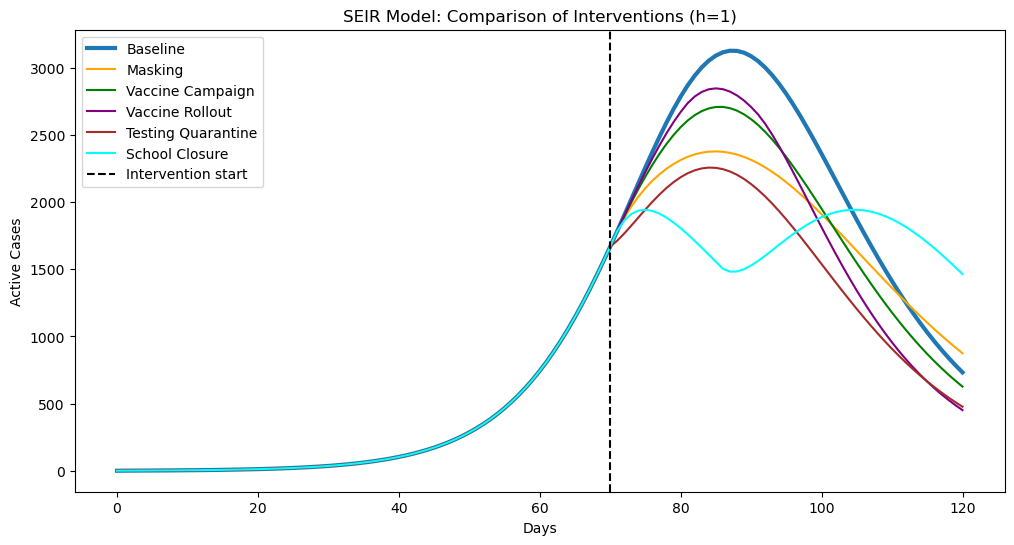

In [1]:
#%%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#%%
# --- 1. LOAD DATA ---
data3_df = pd.read_csv('/Users/megansullivan/Desktop/Comp BME/Module-2-epidemics-SIR-modeling/Data/mystery_virus_daily_active_counts_RELEASE#3.csv')
day3_data = data3_df['day'].values
obs_i = data3_df['active reported daily cases'].values

#%%
# --- 2. PARAMETERS ---
N = 17900
S0 = N - 5
E0 = 5
I0 = 1
R0_init = 0
h = 1  # 1 day per step

#%%
# --- 3. SEIR MODEL (Euler method with interventions) ---
def euler_seir(t_max, N, S0, E0, I0, R0_val, beta, sigma, gamma, intervention=None):
    timepoints = np.arange(0, t_max + 1, 1)
    S = np.zeros(len(timepoints))
    E = np.zeros(len(timepoints))
    I = np.zeros(len(timepoints))
    R = np.zeros(len(timepoints))
    S[0], E[0], I[0], R[0] = S0, E0, I0, R0_val

    for n in range(len(timepoints)-1):
        t = timepoints[n]
        beta_t = beta
        gamma_t = gamma

        # --- INTERVENTIONS ---
        if intervention == "masking" and t >= 70:
            beta_t = beta * 0.6  # 40% reduction in transmission

        if intervention == "vaccine_campaign" and t == 70:
            vaccinated = min(2000 * 0.9, S[n])
            S[n] -= vaccinated
            R[n] += vaccinated

        if intervention == "vaccine_rollout" and t in [70, 80, 90]:
            vaccinated = min(1000 * 0.9, S[n])
            S[n] -= vaccinated
            R[n] += vaccinated

        if intervention == "testing_quarantine" and t >= 70:
            # Reduce infectious period by 2 days: gamma_new = 1/(original infectious period -2)
            gamma_t = 1 / (1/gamma - 2)

        if intervention == "school_closure" and 70 <= t <= 84:
            beta_t = beta * 0.2  # 20% of normal contacts

        # --- SEIR EQUATIONS ---
        dS = -beta_t * S[n] * I[n] / N
        dE = beta_t * S[n] * I[n] / N - sigma * E[n]
        dI = sigma * E[n] - gamma_t * I[n]
        dR = gamma_t * I[n]

        S[n+1] = S[n] + dS
        E[n+1] = E[n] + dE
        I[n+1] = I[n] + dI
        R[n+1] = R[n] + dR

    return timepoints, S, E, I, R

#%%
# --- 4. GRID SEARCH CALIBRATION ---
beta_range = np.linspace(0.3,0.5,12)
sigma_range = np.linspace(1/15,1/10,4)
gamma_range = np.linspace(0.08,0.15,4)

best_sse = float('inf')
best_params = (0,0,0)
t_max = max(day3_data)

for b in beta_range:
    for s in sigma_range:
        for g in gamma_range:
            t, S, E, I_model, R = euler_seir(t_max, N, S0, E0, I0, R0_init, b, s, g)
            model_matches = I_model[day3_data.astype(int)]
            sse = np.sum((model_matches - obs_i)**2)
            if sse < best_sse:
                best_sse = sse
                best_params = (b, s, g)

print("Best parameters (beta, sigma, gamma):", best_params)

#%%
# --- 5. BASELINE MODEL ---
t_base, S_b, E_b, I_b, R_b = euler_seir(120, N, S0, E0, I0, R0_init, *best_params)

#%%
# --- 6. INTERVENTION SIMULATIONS ---
interventions = ["masking", "vaccine_campaign", "vaccine_rollout", "testing_quarantine", "school_closure"]
results = {}

for intervention in interventions:
    t_i, S_i, E_i, I_i, R_i = euler_seir(120, N, S0, E0, I0, R0_init, *best_params, intervention=intervention)
    results[intervention] = I_i

#%%
# --- 7. PEAK COMPARISON ---
print("\n--- PEAK INFECTIONS ---")
print("Baseline:", np.max(I_b))
for intervention in interventions:
    print(f"{intervention}: {np.max(results[intervention])}")

#%%
# --- 8. CASES PREVENTED (days 70-120) ---
start = 70
baseline_cases = np.sum(I_b[start:])
print("\n--- CASES PREVENTED (days 70-120) ---")
for intervention in interventions:
    cases_prevented = baseline_cases - np.sum(results[intervention][start:])
    print(f"{intervention}: {cases_prevented:.0f}")

#%%
# --- 9. VISUALIZATION ---
plt.figure(figsize=(12,6))
plt.plot(t_base, I_b, label="Baseline", linewidth=3)
colors = ['orange','green','purple','brown','cyan']
for color, intervention in zip(colors, interventions):
    plt.plot(t_base, results[intervention], label=intervention.replace("_"," ").title(), color=color)
plt.axvline(70, color='black', linestyle='--', label="Intervention start")
plt.xlabel("Days")
plt.ylabel("Active Cases")
plt.title("SEIR Model: Comparison of Interventions (h=1)")
plt.legend()
plt.show()

## Verify and validate your analysis: 

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*